In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/online_retail_II.csv')

In [ ]:
df.shape

(1067371, 8)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None


In [ ]:
print(df.describe())

           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4.649388e+00   15324.638504
std    1.727058e+02  1.235531e+02    1697.464450
min   -8.099500e+04 -5.359436e+04   12346.000000
25%    1.000000e+00  1.250000e+00   13975.000000
50%    3.000000e+00  2.100000e+00   15255.000000
75%    1.000000e+01  4.150000e+00   16797.000000
max    8.099500e+04  3.897000e+04   18287.000000


In [ ]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df['Description']=df['Description'].fillna('unknown')
df['Customer ID']=df['Customer ID'].fillna('Guest')
cancelled_order=df[df['Invoice'].astype(str).str.startswith('C')]
print("Total cancelled orders:",len(cancelled_order))
df=df[df['Quantity']>0]
df=df[df['Price']>0]


Total cancelled orders: 19494


In [ ]:
print(df.isnull().sum())

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


Text(0.5, 1.0, 'Price')

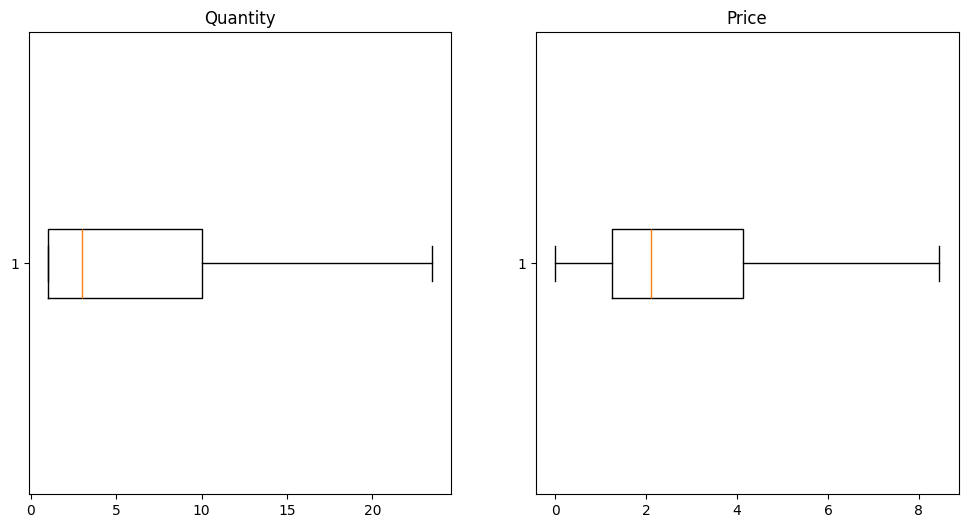

In [ ]:
#Finding Outlier
Q1=df['Quantity'].quantile(0.25)
Q3=df['Quantity'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['Quantity']=df['Quantity'].clip(lower=lower,upper=upper)

Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['Price']=df['Price'].clip(lower=lower,upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].boxplot(df['Quantity'],vert=False)
axes[0].set_title("Quantity")
axes[1].boxplot(df['Price'],vert=False)
axes[1].set_title("Price")


In [ ]:
#Feature Engineering |
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['hours']=df['InvoiceDate'].dt.hour
df['Day']=df['InvoiceDate'].dt.day
df['month']=df['InvoiceDate'].dt.month
df['dayofweek']=df['InvoiceDate'].dt.day_of_week
df['weekend']=df['InvoiceDate'].isin([7,1]).astype(int)
df['Revenue']=df['Quantity']*df['Price'].astype(int)
df['Demand']=df.groupby('Description')['Quantity'].transform('sum')
df['Avg_price']=df.groupby('Description')['Price'].transform('mean')
df['Transaction_count']=df.groupby('Description')['Invoice'].transform('count')
df['Customer_freq']=df.groupby('Customer ID')['Invoice'].transform('count')
df['Customer_spending']=df.groupby('Customer ID')['Revenue'].transform('mean')

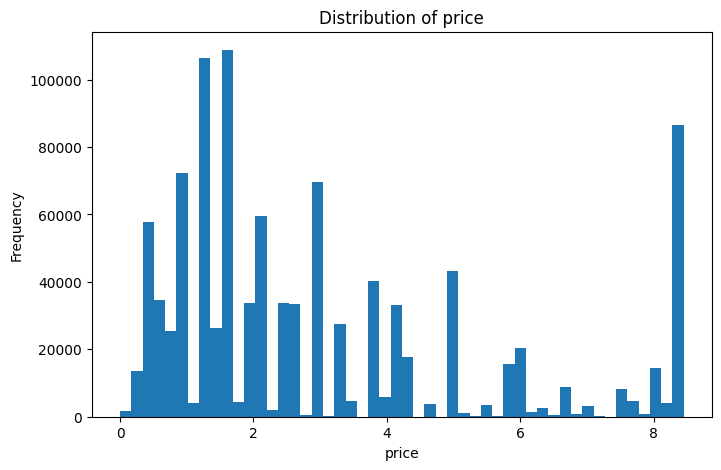

In [ ]:
#EDA
plt.figure(figsize=(8,5))
plt.hist(df['Price'],bins=50)
plt.xlabel('price')
plt.ylabel('Frequency')
plt.title('Distribution of price')
plt.show()

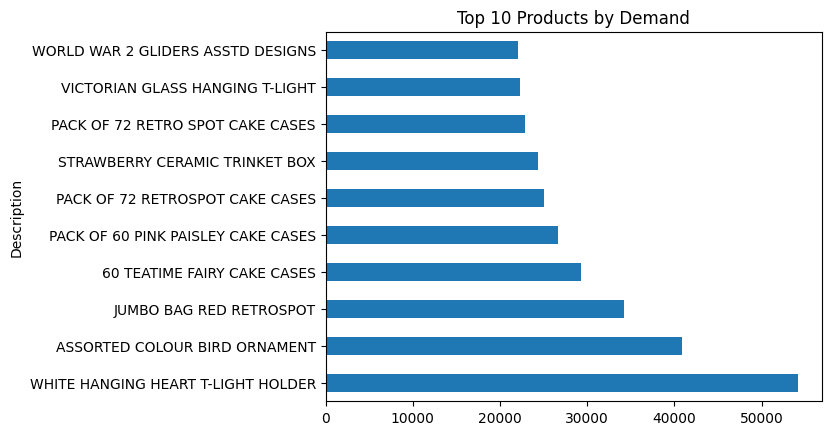

In [ ]:
df.groupby('Description')['Quantity'].sum().nlargest(10).plot(kind='barh')
plt.title('Top 10 Products by Demand')
plt.show()

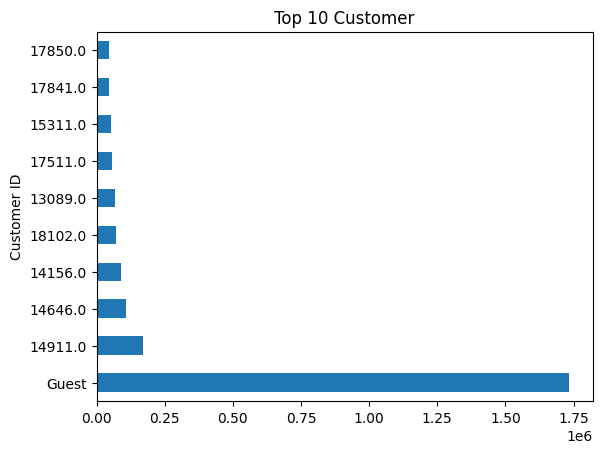

In [ ]:
top_cust=df.groupby('Customer ID')['Revenue'].sum().nlargest(10)
top_cust.plot(kind='barh')
plt.title('Top 10 Customer')
plt.show()

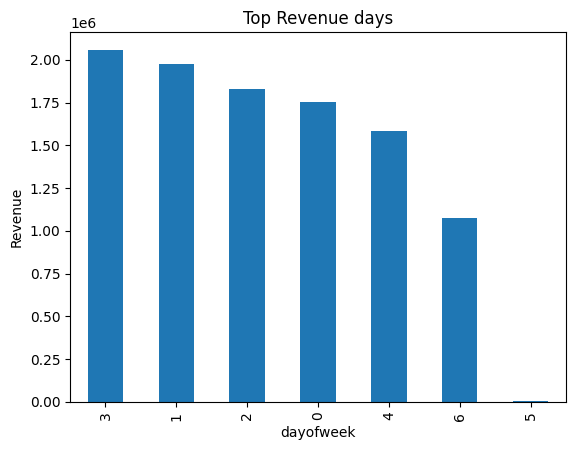

In [ ]:
sales_day=df.groupby('dayofweek')['Revenue'].sum().nlargest(7).plot(kind='bar')
plt.title('Top Revenue days')
plt.ylabel('Revenue')
plt.show()

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'hours', 'Day', 'month', 'dayofweek',
       'weekend', 'Revenue', 'Demand', 'Avg_price', 'Transaction_count',
       'Customer_freq', 'Customer_spending', 'Countryencode'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()
df['Countryencode']=le.fit_transform(df['Country'])
df['Description']=le.fit_transform(df['Description'])
df['StockCodeencode']=le.fit_transform(df['StockCode'])

In [ ]:
features=[ 'Quantity', 'Revenue', 'Countryencode', 'StockCodeencode']
X=df[features]
y=df['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)


RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import root_mean_squared_error,r2_score,mean_absolute_error
y_pred=model.predict(X_test)
print(f"MAE:{mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE:{root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R²Score:{r2_score(y_test, y_pred):.2f}")

MAE: 0.03
MAE: 0.03
RMSE: 0.08
R² Score: 1.00
